In [29]:
# ---- Imports ----
import io
import pathlib

import coiled
import dask
import icechunk as ic
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import yaml
from azure.identity import DefaultAzureCredential
from matplotlib.colors import BoundaryNorm, ListedColormap
from PIL import Image as PILImage

In [7]:
# ---- Config ----
ICECHUNK_ACCOUNT   = 'spaceintelliexternal'
ICECHUNK_CONTAINER = 'earthmover'
ICECHUNK_PREFIX    = 'ghl/2025/v1'

ASSETS_PATH = pathlib.Path('assets.yaml')
with ASSETS_PATH.open() as f:
    assets_cfg = yaml.safe_load(f)
YEAR = int(list(assets_cfg['dates'].keys())[0])

credential = DefaultAzureCredential()

In [8]:
# ---- Coiled cluster for distributed reads ----
# Coiled prefers uv.lock when present; disable so workers sync the full installed env.
dask.config.set({'coiled.package_sync.use_lockfile.uv': False})

cluster = coiled.Cluster(
    workspace='si-dev',
    n_workers=[1, 4],
    worker_vm_types=['Standard_E4ds_v6'],
    scheduler_vm_types=['Standard_E2ds_v6'],
    spot_policy='spot',
)

client = cluster.get_client()
print(client)
print('Dashboard:', client.dashboard_link)

Output()

╭──────────────────────────────── Package Info ────────────────────────────────╮
│                                ╷                                             │
│   Package                      │ Note                                        │
│ ╶──────────────────────────────┼───────────────────────────────────────────╴ │
│   coiled_local_ghl             │ Source wheel built from                     │
│                                │ ~/PycharmProjects/si-integrations/integra   │
│                                │ tions/earthmover/ghl                        │
│   coiled_local_jupyter_debug   │ Source wheel built from                     │
│                                │ ~/Applications/PyCharm.app/Contents/plugi   │
│                                │ ns/python-ce/helpers/jupyter_debug          │
│   coiled_local_pydev           │ Source wheel built from                     │
│                                │ ~/Applications/PyCharm.app/Contents/plugi   │
│                                │ ns/python-ce/helpers/pydev                  │
│   coiled_local_si_integrations │ Source wheel built from                     │
│                                │ ~/PycharmProjects/si-integrations           │
│   python                       │ https://conda.anaconda.org/conda-forge/,c   │
│                                │ onda-forge                                  │
│                                ╵                                             │
╰──────────────────────────────────────────────────────────────────────────────╯

Output()

<Client: 'tls://10.8.0.49:8786' processes=0 threads=0, memory=0 B>
Dashboard: https://cluster-msjlb.dask.host/v4dW6u3M2Vw_Lie5/status


2026-06-09 12:47:50,958 - distributed.client - ERROR - Failed to reconnect to scheduler after 30.00 seconds, closing client
2026-06-09 12:47:52,544 - distributed.deploy.adaptive - WARNING - Adaptive encountered an error while adapting
Traceback (most recent call last):
  File "/Users/alexandermackie/PycharmProjects/si-integrations/.venv/lib/python3.12/site-packages/distributed/utils.py", line 1928, in wait_for
    return await fut
           ^^^^^^^^^
  File "/Users/alexandermackie/PycharmProjects/si-integrations/.venv/lib/python3.12/site-packages/distributed/comm/tcp.py", line 547, in connect
    stream = await self.client.connect(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/alexandermackie/PycharmProjects/si-integrations/.venv/lib/python3.12/site-packages/tornado/tcpclient.py", line 279, in connect
    af, addr, stream = await connector.start(connect_timeout=timeout)
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
asyncio.exceptions.CancelledError

Th

In [ ]:
# ---- Shared colormap definitions ----
LC_COLORS = ['#234626','#236656','#7E52B6','#F0E442','#F8AC6B',
             '#B4B4B4','#B4B4B4','#DDDDDD','#468FAF','#FFFF8C']
LC_LABELS = ['Tree cover','Mangrove','Plantation','Grassland/shrubland',
             'Cropland','Built-up','Bare/sparse veg','Snow/ice','Water','Flooded veg']
lc_cmap = ListedColormap(LC_COLORS)
lc_norm = BoundaryNorm(np.arange(0.5, 11.5, 1), ncolors=10)

DEFOR_COLORS = ['#FFFFFF',
                '#FFF7BC','#FEE391','#FEC44F','#FE9929','#EC7014','#CC4C02',
                '#B03007','#993404','#8B0000','#7A0000','#680000','#520000',
                '#3D0000','#1A0000']
defor_cmap = ListedColormap(DEFOR_COLORS)
defor_bounds_list = [-0.5, 10.5, 11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5,
                     18.5, 19.5, 20.5, 21.5, 22.5, 23.5, 24.5]
defor_norm = BoundaryNorm(defor_bounds_list, ncolors=len(defor_bounds_list) - 1)

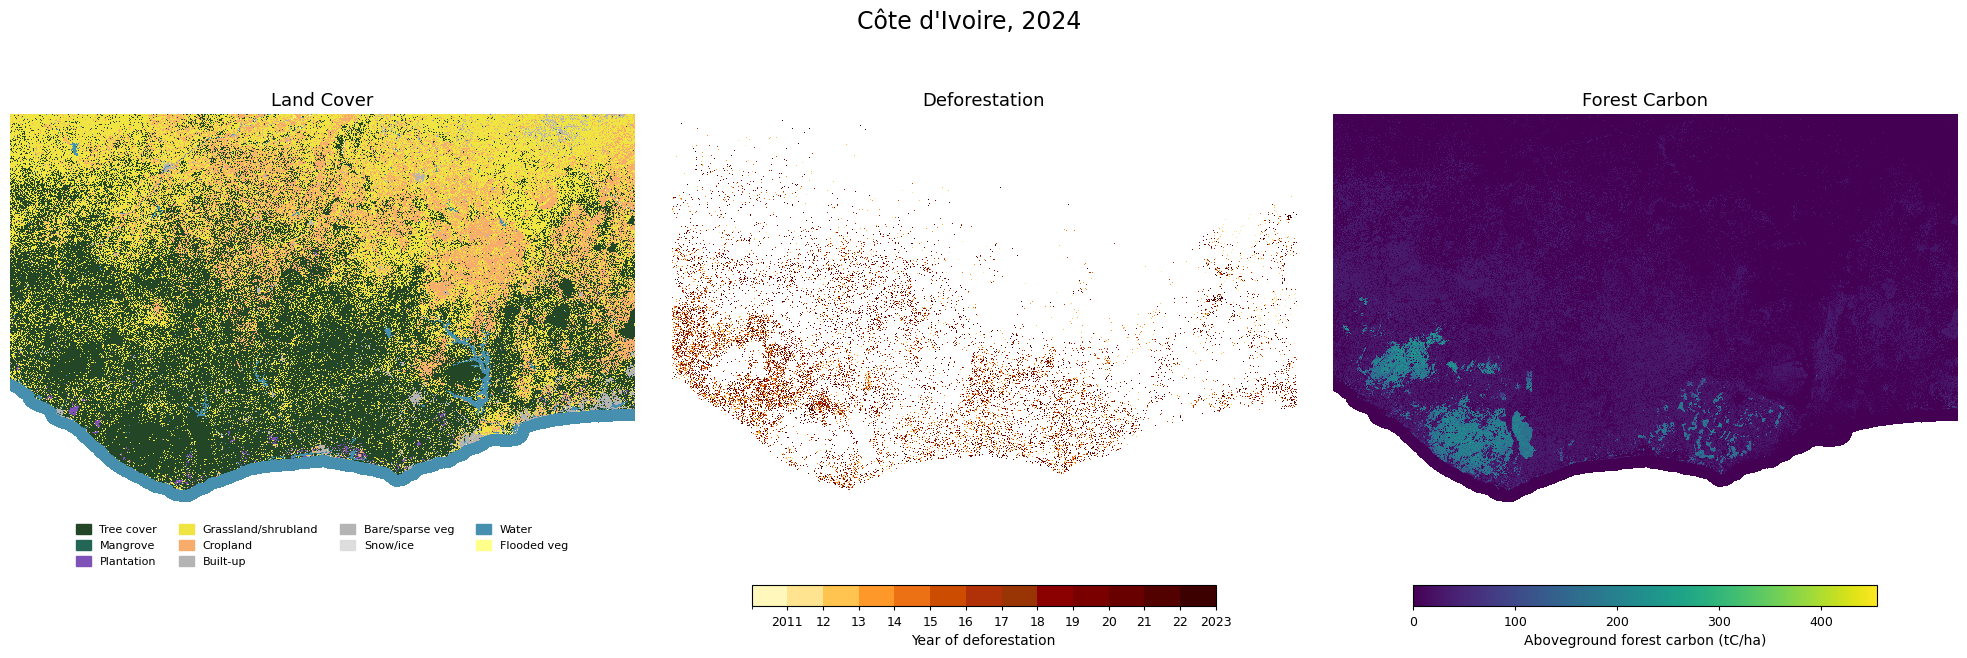

Saved ghl_ivory_coast.png at 300 DPI
Saved ghl_ivory_coast_land_cover.png


/var/folders/c6/v7zjstjs66g0q6kqw3w1vg340000gn/T/ipykernel_67075/1942736134.py:126: UserWarning: Adding colorbar to a different Figure <Figure size 2000x700 with 5 Axes> than <Figure size 700x700 with 2 Axes> which fig.colorbar is called on.
  cbar_s = fig_s.colorbar(cb_im, cax=cax_s, orientation="horizontal")


Saved ghl_ivory_coast_deforestation.png


/var/folders/c6/v7zjstjs66g0q6kqw3w1vg340000gn/T/ipykernel_67075/1942736134.py:126: UserWarning: Adding colorbar to a different Figure <Figure size 2000x700 with 5 Axes> than <Figure size 700x700 with 2 Axes> which fig.colorbar is called on.
  cbar_s = fig_s.colorbar(cb_im, cax=cax_s, orientation="horizontal")


Saved ghl_ivory_coast_forest_carbon.png


In [26]:
# ---- Visualise Ivory Coast from IceChunk ----
minx, miny, maxx, maxy = -12.0, 2.0, 4.0, 14.0

bearer_token = credential.get_token("https://storage.azure.com/.default").token
storage = ic.azure_storage(
    account=ICECHUNK_ACCOUNT,
    container=ICECHUNK_CONTAINER,
    prefix=ICECHUNK_PREFIX,
    bearer_token=bearer_token,
)
repo = ic.Repository.open(storage)
ds = xr.open_dataset(
    repo.readonly_session("main").store,
    engine="zarr",
    consolidated=False,
    chunks={},
)
tile_ds = ds.sel(x=slice(minx, maxx), y=slice(maxy, miny), year=YEAR)

SUBSAMPLE = 10
plot_ds = tile_ds.isel(x=slice(None, None, SUBSAMPLE), y=slice(None, None, SUBSAMPLE)).compute(scheduler=client)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
extent = [minx, maxx, miny, maxy]

# ── Land cover ──────────────────────────────────────────────────────────────────
lc_data = plot_ds["land_cover"].squeeze().values.astype(float)
lc_data[lc_data == 255] = np.nan
axes[0].imshow(lc_data, origin="upper", extent=extent, cmap=lc_cmap, norm=lc_norm, interpolation="none")
handles = [mpatches.Patch(color=c, label=l) for c, l in zip(LC_COLORS, LC_LABELS)]
axes[0].legend(
    handles=handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=4,
    fontsize=8,
    framealpha=0.85,
    edgecolor="none",
    handlelength=1.3,
    handleheight=1.0,
)

# ── Deforestation — stretched 2011–2023 ─────────────────────────────────────────
defor_plot_colors = DEFOR_COLORS[1:14]   # years 2011–2023
defor_plot_cmap = ListedColormap(defor_plot_colors)
defor_plot_bounds = [10.5 + i for i in range(14)]
defor_plot_norm = BoundaryNorm(defor_plot_bounds, ncolors=13)

defor_data = plot_ds["deforestation"].squeeze().values.astype(float)
defor_data[defor_data == 255] = np.nan
defor_data[defor_data == 0]   = np.nan
defor_data[defor_data == 24]  = np.nan
im_d = axes[1].imshow(defor_data, origin="upper", extent=extent,
                      cmap=defor_plot_cmap, norm=defor_plot_norm, interpolation="none")

# ── Forest carbon ───────────────────────────────────────────────────────────────
fc_data = plot_ds["forest_carbon"].squeeze().values.astype(float)
fc_data[fc_data == 65535] = np.nan
im_fc = axes[2].imshow(fc_data, origin="upper", extent=extent,
                       cmap="viridis", vmin=0, vmax=455, interpolation="none")

# ── Panel subtitles ────────────────────────────────────────────────────────────
axes[0].set_title("Land Cover",          fontsize=13, pad=6)
axes[1].set_title("Deforestation",       fontsize=13, pad=6)
axes[2].set_title("Forest Carbon",       fontsize=13, pad=6)

# ── Remove map axes decoration ──────────────────────────────────────────────────
for ax in axes:
    ax.set_axis_off()

plt.suptitle(f"Côte d'Ivoire, {YEAR} ", fontsize=17)
plt.tight_layout(rect=[0, 0.08, 1, 0.97])

# ── Colorbars — added AFTER tight_layout using figure-fraction coordinates ──────
# This avoids any clipping caused by set_axis_off() on the parent axes.
fig.canvas.draw()   # forces layout so get_position() returns correct values

CB_H     = 0.03    # colorbar height in figure fraction
CB_PAD   = 0.005   # gap below the axes
CB_INSET = 0.04    # horizontal inset from each side

def add_colorbar(ax, im, ticks, ticklabels, label, **kw):
    pos = ax.get_position()
    cax = fig.add_axes([
        pos.x0 + CB_INSET,
        pos.y0 - CB_H - CB_PAD,
        pos.width - 2 * CB_INSET,
        CB_H,
    ])
    cbar = fig.colorbar(im, cax=cax, orientation="horizontal", **kw)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels(ticklabels, fontsize=9)
    cbar.set_label(label, fontsize=10, labelpad=4)
    cbar.ax.tick_params(length=3, labelsize=9)
    return cbar

# Deforestation: one tick per year band centre
defor_ticks = [11 + i + 0.5 for i in range(13)]
defor_labels = ["2011"] + [str(12 + i) for i in range(11)] + ["2023"]
add_colorbar(axes[1], im_d, defor_ticks, defor_labels, "Year of deforestation")

# Forest carbon
add_colorbar(axes[2], im_fc, [0, 100, 200, 300, 400], ["0", "100", "200", "300", "400"],
             "Aboveground forest carbon (tC/ha)")

fig.savefig("ghl_ivory_coast.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved ghl_ivory_coast.png at 300 DPI")
# ── Save each panel as an individual file ───────────────────────────────────────
def save_panel(data, cmap, norm, filename, title, legend_handles=None,
               cb_im=None, cb_ticks=None, cb_labels=None, cb_label=None):
    fig_s, ax_s = plt.subplots(figsize=(7, 7))
    ax_s.imshow(data, origin="upper", extent=extent, cmap=cmap, norm=norm, interpolation="none")
    ax_s.set_title(title, fontsize=13, pad=6)
    if legend_handles:
        ax_s.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, 0.01),
                    ncol=4, fontsize=8, framealpha=0.85, edgecolor="none",
                    handlelength=1.3, handleheight=1.0)
    ax_s.set_axis_off()
    plt.tight_layout(rect=[0, 0.06 if cb_im else 0, 1, 1])
    if cb_im is not None:
        fig_s.canvas.draw()
        pos = ax_s.get_position()
        cax_s = fig_s.add_axes([pos.x0 + CB_INSET, pos.y0 - CB_H - CB_PAD,
                                pos.width - 2 * CB_INSET, CB_H])
        cbar_s = fig_s.colorbar(cb_im, cax=cax_s, orientation="horizontal")
        cbar_s.set_ticks(cb_ticks)
        cbar_s.set_ticklabels(cb_labels, fontsize=9)
        cbar_s.set_label(cb_label, fontsize=10, labelpad=4)
        cbar_s.ax.tick_params(length=3, labelsize=9)
    fig_s.savefig(filename, dpi=300, bbox_inches="tight")
    plt.close(fig_s)
    print(f"Saved {filename}")

save_panel(lc_data, lc_cmap, lc_norm,
           "ghl_ivory_coast_land_cover.png", f"Land Cover, {YEAR}",
           legend_handles=handles)

save_panel(defor_data, defor_plot_cmap, defor_plot_norm,
           "ghl_ivory_coast_deforestation.png", f"Deforestation, {YEAR}",
           cb_im=im_d, cb_ticks=defor_ticks, cb_labels=defor_labels,
           cb_label="Year of deforestation")

save_panel(fc_data, plt.cm.viridis, None,
           "ghl_ivory_coast_forest_carbon.png", f"Forest Carbon, {YEAR}",
           cb_im=im_fc, cb_ticks=[0, 100, 200, 300, 400],
           cb_labels=["0", "100", "200", "300", "400"],
           cb_label="Aboveground forest carbon (tC/ha)")

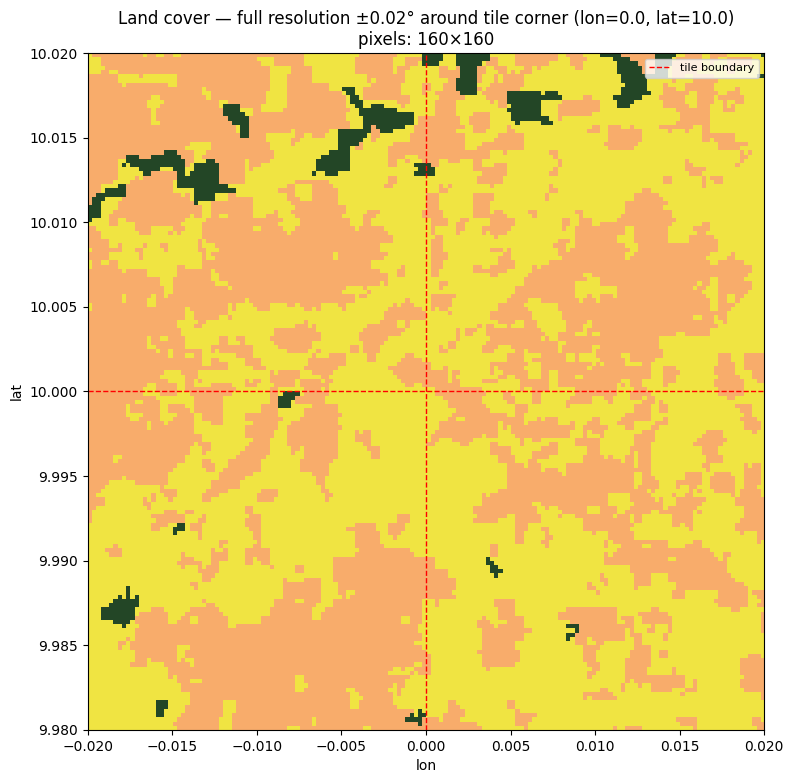

In [14]:
# ---- Tile-boundary check: full-resolution land cover at the 4-tile corner (lon=0, lat=10) ----
# Tiles meeting here: 10N_010W, 10N_000E, 20N_010W, 20N_000E
# ±0.1° = 800×800 px — small enough to load at full resolution, large enough to see the seam.
CORNER_BUFFER = 0.02  # ±0.02° = 160×160 px — shows individual pixels clearly
corner_lon, corner_lat = 0.0, 10.0

bearer_token = credential.get_token("https://storage.azure.com/.default").token
storage = ic.azure_storage(
    account=ICECHUNK_ACCOUNT, container=ICECHUNK_CONTAINER,
    prefix=ICECHUNK_PREFIX, bearer_token=bearer_token,
)
repo = ic.Repository.open(storage)
ds = xr.open_dataset(repo.readonly_session("main").store, engine="zarr", consolidated=False, chunks={})

corner_ds = ds["land_cover"].sel(
    x=slice(corner_lon - CORNER_BUFFER, corner_lon + CORNER_BUFFER),
    y=slice(corner_lat + CORNER_BUFFER, corner_lat - CORNER_BUFFER),
    year=YEAR,
).compute(scheduler=client)

lc_data = corner_ds.squeeze().values.astype(float)
lc_data[lc_data == 255] = np.nan

fig, ax = plt.subplots(figsize=(8, 8))
extent = [corner_lon - CORNER_BUFFER, corner_lon + CORNER_BUFFER,
          corner_lat - CORNER_BUFFER, corner_lat + CORNER_BUFFER]
ax.imshow(lc_data, origin="upper", extent=extent, cmap=lc_cmap, norm=lc_norm, interpolation="none")
# Mark the tile boundary lines
ax.axvline(corner_lon, color="red", linewidth=1, linestyle="--", label="tile boundary")
ax.axhline(corner_lat, color="red", linewidth=1, linestyle="--")
ax.set_xlabel("lon"); ax.set_ylabel("lat")
ax.legend(loc="upper right", fontsize=8)
ax.set_title(
    f"Land cover — full resolution ±{CORNER_BUFFER}° around tile corner (lon={corner_lon}, lat={corner_lat})\n"
    f"pixels: {lc_data.shape[1]}×{lc_data.shape[0]}"
)
plt.tight_layout()
plt.show()

In [19]:
# ---- Landscape-scale GIF: Central Amazon deforestation — with zoom-out ----
# Fetches data at the widest extent; each key frame is rendered at a progressively
# wider crop window, creating a smooth zoom-out across the animation.
import io
from PIL import Image as PILImage

DPI = 100

def fig_to_pil(fig):
    """Render a matplotlib figure to a PIL Image (no whitespace padding)."""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=DPI, bbox_inches="tight", pad_inches=0)
    plt.close(fig)
    buf.seek(0)
    return PILImage.open(buf).copy().resize((400, 300), PILImage.LANCZOS)


# EPSG 6933 point (-5810530E, -1257470N) → WGS84 lon=-60.22°, lat=-9.90°
# Central Amazon, Brazil — active deforestation hotspot
_CENTER_LON, _CENTER_LAT = -60.2213, -9.9048

# Zoom schedule: animation starts zoomed in, ends zoomed out
_AOI_HALF_Y = 0.33              # ±0.33° latitude  → ~37 km
_AOI_HALF_X = 0.44              # ±0.44° longitude → ~49 km  (4:3 ratio with _AOI_HALF_Y)
_AOI_HALF_FETCH_Y = _AOI_HALF_Y + 0.02
_AOI_HALF_FETCH_X = _AOI_HALF_X + 0.02


LANDSCAPE_LABEL = "Central Amazon, Brazil"
LANDSCAPE_SUBSAMPLE = 2  # every 2px → ~60m

# Fetch data at the maximum (widest) extent once
bearer_token = credential.get_token("https://storage.azure.com/.default").token
storage = ic.azure_storage(
    account=ICECHUNK_ACCOUNT, container=ICECHUNK_CONTAINER,
    prefix=ICECHUNK_PREFIX, bearer_token=bearer_token,
)
repo = ic.Repository.open(storage)
ds = xr.open_dataset(repo.readonly_session("main").store, engine="zarr", consolidated=False, chunks={})

landscape_raw = (
    ds.sel(
        x=slice(_CENTER_LON - _AOI_HALF_FETCH_X, _CENTER_LON + _AOI_HALF_FETCH_X),
        y=slice(_CENTER_LAT + _AOI_HALF_FETCH_Y, _CENTER_LAT - _AOI_HALF_FETCH_Y),
        year=YEAR,
    )
    .isel(x=slice(None, None, LANDSCAPE_SUBSAMPLE), y=slice(None, None, LANDSCAPE_SUBSAMPLE))
    .compute(scheduler=client)
)

_full_lc    = landscape_raw["land_cover"].squeeze().values.astype(float);    _full_lc[_full_lc == 255]       = np.nan
_full_defor = landscape_raw["deforestation"].squeeze().values.astype(float); _full_defor[_full_defor == 255]  = np.nan
_full_fc    = landscape_raw["forest_carbon"].squeeze().values.astype(float); _full_fc[_full_fc == 65535]      = np.nan
_xv = landscape_raw.x.values   # 1-D, ascending
_yv = landscape_raw.y.values   # 1-D, descending (north → south)

LS_FIGSIZE = (4, 3)  # 400×300 px at DPI=100

def _bare_ax(ax):
    ax.set_axis_off()

def crossfade(img_a, img_b, steps=8):
    """Return steps blended PIL frames transitioning from img_a to img_b."""
    a = img_a.convert("RGBA")
    b = img_b.convert("RGBA")
    if b.size != a.size:
        b = b.resize(a.size, PILImage.LANCZOS)
    return [PILImage.blend(a, b, i / (steps + 1)).convert("RGB") for i in range(1, steps + 1)]

def crop_at_zoom(arr_full, half_x, half_y):
    """Return (cropped_array, imshow_extent) for a ±half_x/half_y window around centre."""
    xi = np.where((_xv >= _CENTER_LON - half_x) & (_xv <= _CENTER_LON + half_x))[0]
    yi = np.where((_yv >= _CENTER_LAT - half_y) & (_yv <= _CENTER_LAT + half_y))[0]
    if len(xi) == 0 or len(yi) == 0:
        return arr_full, [_xv[0], _xv[-1], _yv[-1], _yv[0]]
    cropped = arr_full[yi[0] : yi[-1] + 1, xi[0] : xi[-1] + 1]
    # extent for imshow: [left, right, bottom, top]
    extent = [_xv[xi[0]], _xv[xi[-1]], min(_yv[yi[0]], _yv[yi[-1]]), max(_yv[yi[0]], _yv[yi[-1]])]
    return cropped, extent



# Fixed zoom: all frames rendered at _AOI_HALF



# ── Helper: render a deforestation frame at a given zoom ──────────────────────
def make_defor_frame(up_to_year_code, half_x, half_y):
    """White-background deforestation ≤ up_to_year_code, cropped to half_x/half_y."""
    _dc = ListedColormap(DEFOR_COLORS)
    _dc.set_bad(color="white", alpha=1)
    d, ext = crop_at_zoom(_full_defor, half_x, half_y)
    d = d.copy()
    d[(d == 0) | (d > up_to_year_code)] = np.nan
    fig, ax = plt.subplots(figsize=LS_FIGSIZE)
    ax.set_facecolor("white"); fig.patch.set_facecolor("white")
    ax.imshow(d, origin="upper", extent=ext, cmap=_dc, norm=defor_norm, interpolation="none")
    _bare_ax(ax); plt.tight_layout(pad=0)
    return fig_to_pil(fig)

# ── Helper: render the land-cover frame at a given zoom ───────────────────────
def make_lc_frame(half_x, half_y):
    arr, ext = crop_at_zoom(_full_lc, half_x, half_y)
    fig, ax = plt.subplots(figsize=LS_FIGSIZE)
    ax.imshow(arr, origin="upper", extent=ext, cmap=lc_cmap, norm=lc_norm, interpolation="none")
    _bare_ax(ax); plt.tight_layout(pad=0)
    return fig_to_pil(fig)

# ── Helper: render the forest-carbon frame at a given zoom ────────────────────
def make_fc_frame(half_x, half_y):
    arr, ext = crop_at_zoom(_full_fc, half_x, half_y)
    arr = arr.copy(); arr[arr == 0] = np.nan
    valid = arr[~np.isnan(arr)]
    vmin = float(np.percentile(valid, 2))  if len(valid) else 1
    vmax = float(np.percentile(valid, 98)) if len(valid) else 455
    _cmap = plt.get_cmap("viridis").copy(); _cmap.set_bad(alpha=0)
    fig, ax = plt.subplots(figsize=LS_FIGSIZE)
    ax.imshow(arr, origin="upper", extent=ext, cmap=_cmap, vmin=vmin, vmax=vmax, interpolation="none")
    _bare_ax(ax); plt.tight_layout(pad=0)
    return fig_to_pil(fig)

# ── Build all key frames ───────────────────────────────────────────────────────
HOLD_MS       = 4000   # LC and FC hold — equal to defor section total
FADE_STEPS    = 8
FADE_STEP_MS  = 60
YEAR_HOLD_MS  = 250    # 11 frames x 250ms + 10 fades x 2 x 60ms ≈ 4000ms
YEAR_FADE     = 2      # quick crossfades between years


# Deforestation key frames, one per beat slot 0–5
defor_year_seq = [(yc, YEAR_HOLD_MS) for yc in range(14, 25)]  # 2014–2024
defor_key_frames = [make_defor_frame(yc, _AOI_HALF_X, _AOI_HALF_Y) for yc, _ in defor_year_seq]
defor_holds      = [dur for _, dur in defor_year_seq]

kf_lc = make_lc_frame(_AOI_HALF_X, _AOI_HALF_Y)
kf_fc = make_fc_frame(_AOI_HALF_X, _AOI_HALF_Y)

# ── Assemble: deforestation → land cover → forest carbon (looping) ─────────────
all_frames    = []
all_durations = []

# Part 1: progressive deforestation with short crossfades between years
for i, (df, dur) in enumerate(zip(defor_key_frames, defor_holds)):
    all_frames.append(df); all_durations.append(dur)
    if i < len(defor_key_frames) - 1:
        for f in crossfade(df, defor_key_frames[i + 1], steps=YEAR_FADE):
            all_frames.append(f); all_durations.append(FADE_STEP_MS)

# Part 2: crossfade last defor → land cover, hold
for f in crossfade(defor_key_frames[-1], kf_lc, steps=FADE_STEPS):
    all_frames.append(f); all_durations.append(FADE_STEP_MS)
all_frames.append(kf_lc); all_durations.append(HOLD_MS)

# Part 3: crossfade land cover → forest carbon, hold
for f in crossfade(kf_lc, kf_fc, steps=FADE_STEPS):
    all_frames.append(f); all_durations.append(FADE_STEP_MS)
all_frames.append(kf_fc); all_durations.append(HOLD_MS)

# Loop back: crossfade forest carbon → first defor frame
for f in crossfade(kf_fc, defor_key_frames[0], steps=FADE_STEPS):
    all_frames.append(f); all_durations.append(FADE_STEP_MS)

# ── Save GIF ───────────────────────────────────────────────────────────────────
LS_GIF_PATH = pathlib.Path("ghl_landscape_animation.gif")
all_frames[0].save(
    LS_GIF_PATH,
    save_all=True,
    append_images=all_frames[1:],
    duration=all_durations,
    loop=0,
)
print(f"Landscape GIF saved → {LS_GIF_PATH.resolve()}  ({LS_GIF_PATH.stat().st_size / 1024:.0f} KB)")
print(f"Landscape GIF saved -> {LS_GIF_PATH.resolve()}  ({LS_GIF_PATH.stat().st_size / 1024:.0f} KB), {len(all_frames)} total frames")

Landscape GIF saved → /Users/alexandermackie/PycharmProjects/si-integrations/integrations/earthmover/ghl/ghl_landscape_animation.gif  (3010 KB)
Landscape GIF saved -> /Users/alexandermackie/PycharmProjects/si-integrations/integrations/earthmover/ghl/ghl_landscape_animation.gif  (3010 KB), 57 total frames


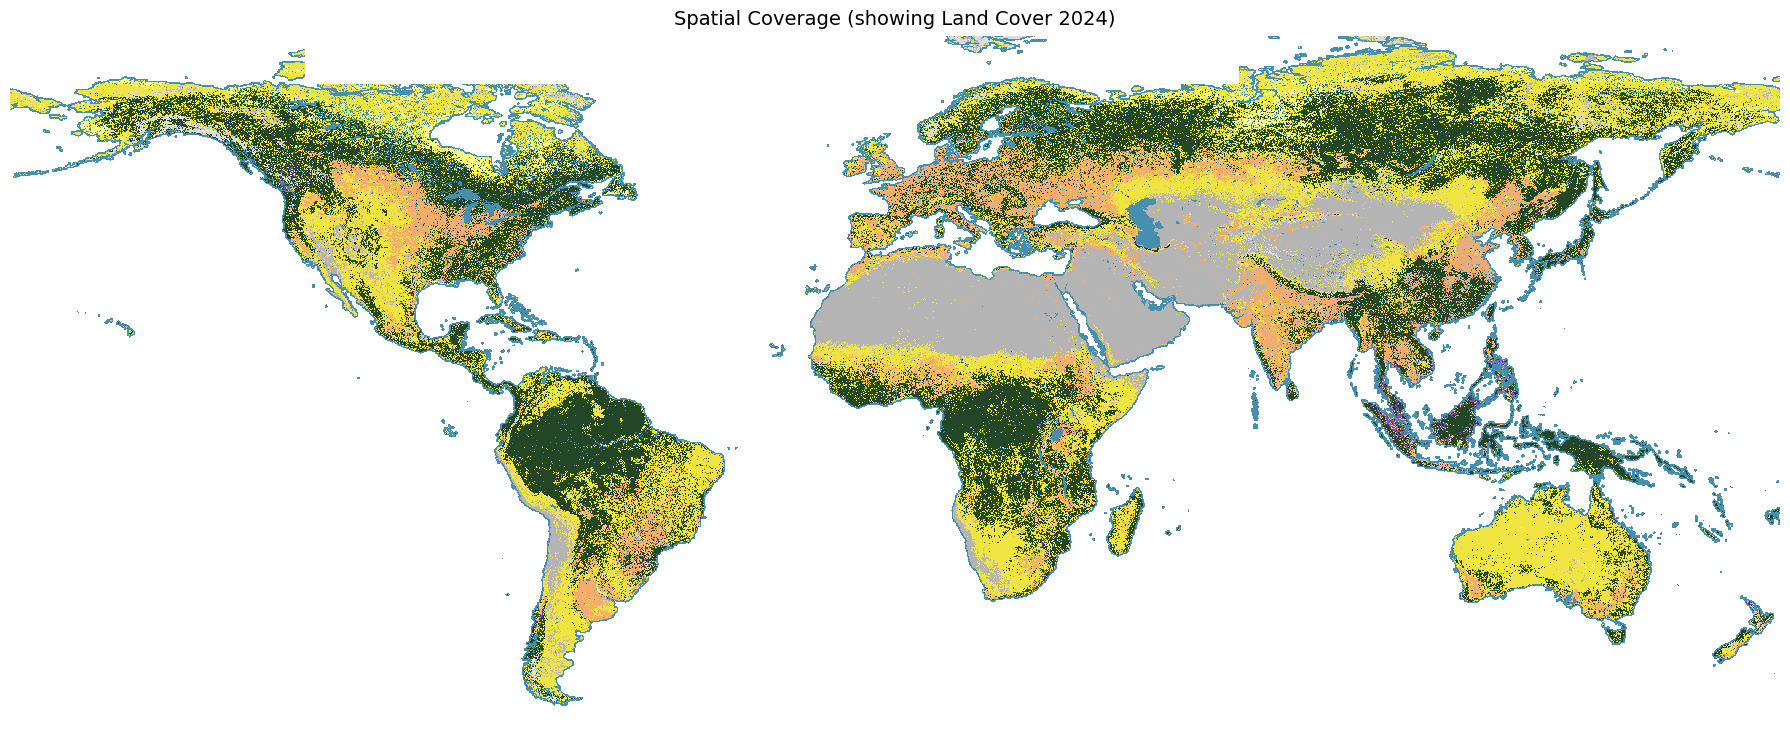

Saved ghl_global_land_cover.png at 300 DPI


In [28]:
# ---- Global overview: very coarse land cover from IceChunk ----
# Subsample every 500px → ~0.125° (~14 km) resolution; covers the full global grid.
SUBSAMPLE = 500

bearer_token = credential.get_token("https://storage.azure.com/.default").token
storage = ic.azure_storage(
    account=ICECHUNK_ACCOUNT, container=ICECHUNK_CONTAINER,
    prefix=ICECHUNK_PREFIX, bearer_token=bearer_token,
)
repo = ic.Repository.open(storage)
ds_global = xr.open_dataset(
    repo.readonly_session("main").store,
    engine="zarr",
    consolidated=False,
    chunks={},
)

global_lc_raw = (
    ds_global["land_cover"]
    .sel(year=YEAR)
    .isel(x=slice(None, None, SUBSAMPLE), y=slice(None, None, SUBSAMPLE))
    .compute(scheduler=client)
)

global_lc = global_lc_raw.values.astype(float)
global_lc[global_lc == 255] = np.nan  # mask nodata

fig, ax = plt.subplots(figsize=(18, 8))
ax.imshow(
    global_lc,
    origin="upper",
    extent=[-180, 180, -60, 80],
    cmap=lc_cmap,
    norm=lc_norm,
    interpolation="none",
)
ax.set_axis_off()
ax.set_title(f"Spatial Coverage (showing Land Cover 2024)", fontsize=14, pad=8)
plt.tight_layout()
fig.savefig("ghl_global_land_cover.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved ghl_global_land_cover.png at 300 DPI")